# DST-DDPM: Dynamic Spatial-Temporal Denoising Diffusion Probabilistic Model

Implementation based on: *Quantifying uncertainty: Air quality forecasting based on dynamic spatial-temporal denoising diffusion probabilistic model* (Chen et al., Environmental Research 2024)

**Architecture:**
1. **Dynamic Context Encoder** — Two T-GCN branches (distance + similarity adjacency) → semantic fusion → learned dynamic adjacency → context embedding
2. **Spatial-Temporal Denoising Model** — Spatial Transformer (attention over nodes) + Temporal Transformer (attention over time) with context fusion gates
3. **Conditional DDPM** — Forward noise on target, reverse denoising conditioned on historical context

**Generalized** to work with any station-based spatio-temporal data (air quality, weather, etc.). Uses random tensors as demo input/target.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
from torch.utils.data import Dataset, DataLoader

## Configuration

In [2]:
class DSTDDPMConfig:
    # Station / data dimensions
    num_stations = 35          # N nodes (stations)
    num_features = 1           # F input features per station per timestep
    hist_len = 8               # T_hist past timesteps (context window)
    pred_len = 8               # T_pred future timesteps to predict

    # Model dimensions
    d_model = 64               # hidden dimension for transformers
    n_heads = 4                # attention heads
    n_layers = 4               # transformer layers (spatial & temporal each)
    d_ff = 128                 # feed-forward inner dimension
    dropout = 0.1
    gcn_hidden = 64            # T-GCN hidden size

    # Context fusion layers (before / after ST-Transformer)
    num_context_before = 1
    num_context_after = 3

    # Diffusion schedule
    diffusion_steps = 100      # K
    beta_start = 1e-4
    beta_end = 5e-2

    # Loss
    gamma = 1.0                # weight for reconstruction loss

    # Training
    lr = 1e-3
    weight_decay = 1e-5
    ema_decay = 0.999
    batch_size = 32
    epochs = 2

config = DSTDDPMConfig()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Stations: {config.num_stations}, Features: {config.num_features}')
print(f'History: {config.hist_len} steps, Prediction: {config.pred_len} steps')

Device: cuda
Stations: 35, Features: 1
History: 8 steps, Prediction: 8 steps


## Generate Random Spatio-Temporal Data & Adjacency Matrices

Replace this cell with real data loading for actual use. The adjacency matrices encode:
- **Distance adjacency** — Gaussian kernel on pairwise station distances (Eq. 14)
- **Similarity adjacency** — cosine similarity of station feature vectors (Eq. 15, POI in paper)

In [3]:
def generate_random_data(config, num_samples=1000, seed=42):
    rng = np.random.default_rng(seed)
    N = config.num_stations

    X = rng.standard_normal((num_samples, config.hist_len, N, config.num_features)).astype(np.float32)
    Y = rng.standard_normal((num_samples, config.pred_len, N, 1)).astype(np.float32)

    # Distance adjacency: Gaussian kernel with threshold (Eq. 14)
    coords = rng.uniform(0, 100, (N, 2))
    dist = np.sqrt(((coords[:, None] - coords[None, :]) ** 2).sum(-1))
    sigma = dist.std()
    kappa = np.percentile(dist, 30)
    A_dist = np.where(dist <= kappa, np.exp(-dist ** 2 / sigma ** 2), 0).astype(np.float32)
    np.fill_diagonal(A_dist, 0)

    # Similarity adjacency: cosine similarity with threshold (Eq. 15)
    feat = rng.uniform(0, 1, (N, 19)).astype(np.float32)
    norms = np.linalg.norm(feat, axis=1, keepdims=True) + 1e-8
    feat_n = feat / norms
    A_sim = (feat_n @ feat_n.T).astype(np.float32)
    A_sim = np.where(A_sim >= 0.5, A_sim, 0)
    np.fill_diagonal(A_sim, 0)

    return X, Y, A_dist, A_sim


X_all, Y_all, A_dist_np, A_sim_np = generate_random_data(config, num_samples=1000)

# 70 / 10 / 20 split
n = len(X_all)
n_train, n_val = int(0.7 * n), int(0.1 * n)
X_train, Y_train = X_all[:n_train], Y_all[:n_train]
X_val, Y_val = X_all[n_train:n_train + n_val], Y_all[n_train:n_train + n_val]
X_test, Y_test = X_all[n_train + n_val:], Y_all[n_train + n_val:]

A_dist = torch.tensor(A_dist_np, device=device)
A_sim = torch.tensor(A_sim_np, device=device)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'A_dist nonzero: {(A_dist_np > 0).sum()}, A_sim nonzero: {(A_sim_np > 0).sum()}')

Train: (700, 8, 35, 1), Val: (100, 8, 35, 1), Test: (200, 8, 35, 1)
A_dist nonzero: 334, A_sim nonzero: 1188


In [4]:
class SpatioTemporalDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


train_loader = DataLoader(SpatioTemporalDataset(X_train, Y_train),
                          batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(SpatioTemporalDataset(X_val, Y_val),
                        batch_size=config.batch_size)
test_loader = DataLoader(SpatioTemporalDataset(X_test, Y_test),
                         batch_size=config.batch_size)

## T-GCN: Temporal Graph Convolutional Network (Fig. 4)

GCN aggregates spatial neighbours at each timestep (Eq. 9), then GRU integrates temporal state (Eq. 10-13).

$$f(X_t, A) = \sigma\bigl(\hat{A} \cdot \text{ReLU}(\hat{A} X W_0) W_1\bigr)$$

$$h_t = z_t \odot h_{t-1} + (1 - z_t) \odot \tilde{h}_t$$

In [5]:
def normalize_adjacency(A):
    """Symmetric normalization: D^{-1/2} (A+I) D^{-1/2}"""
    A_tilde = A + torch.eye(A.size(0), device=A.device)
    D_inv_sqrt = A_tilde.sum(dim=1).clamp(min=1e-8).pow(-0.5)
    return D_inv_sqrt.unsqueeze(1) * A_tilde * D_inv_sqrt.unsqueeze(0)


class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)

    def forward(self, x, A_hat):
        # x: (B, N, F_in), A_hat: (N, N)
        return A_hat @ self.linear(x)


class TGCN(nn.Module):
    """T-GCN: 2-layer GCN per timestep + GRU for temporal integration."""

    def __init__(self, in_features, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.gcn1 = GCNLayer(in_features, hidden_size)
        self.gcn2 = GCNLayer(hidden_size, hidden_size)
        # GRU gates
        self.W_r = nn.Linear(hidden_size * 2, hidden_size)
        self.W_z = nn.Linear(hidden_size * 2, hidden_size)
        self.W_h = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, X, A):
        # X: (B, T, N, F), A: (N, N) raw adjacency
        B, T, N, _ = X.shape
        A_hat = normalize_adjacency(A)
        h = torch.zeros(B, N, self.hidden_size, device=X.device)

        for t in range(T):
            gcn_out = F.relu(self.gcn1(X[:, t], A_hat))
            gcn_out = self.gcn2(gcn_out, A_hat)          # (B, N, hidden)

            cat_rz = torch.cat([gcn_out, h], dim=-1)     # (B, N, 2*hidden)
            r = torch.sigmoid(self.W_r(cat_rz))          # reset gate  (Eq. 10)
            z = torch.sigmoid(self.W_z(cat_rz))          # update gate (Eq. 11)

            cat_h = torch.cat([gcn_out, r * h], dim=-1)
            h_tilde = torch.tanh(self.W_h(cat_h))        # candidate   (Eq. 12)
            h = z * h + (1 - z) * h_tilde                # new state   (Eq. 13)

        return h  # (B, N, hidden)

## Dynamic Context Encoder (Fig. 5)

1. Two T-GCN branches process input with distance adj ($A^D$) and similarity adj ($A^S$)
2. Fuse node embeddings: $z = \text{ReLU}([h^D \oplus h^S] W_s) W_4$ (Eq. 16)
3. Dynamic adjacency: $A^F = \text{Softmax}(\text{ReLU}((z W_f)(z W_f)^T))$ (Eq. 17)
4. Reconstruction loss: $\mathcal{L}_{rec} = \frac{1}{2}(\|A^D - \hat{A}^D\|^2 + \|A^S - \hat{A}^S\|^2)$ (Eq. 19)
5. Context T-GCN with fused adjacency → context embedding

In [6]:
class DynamicContextEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        h = config.gcn_hidden

        # Two T-GCN branches for distance and similarity graphs
        self.tgcn_dist = TGCN(config.num_features, h)
        self.tgcn_sim = TGCN(config.num_features, h)

        # Semantic fusion (Eq. 16)
        self.fusion = nn.Sequential(
            nn.Linear(h * 2, h),
            nn.ReLU(),
            nn.Linear(h, h),
        )

        # Learnable projection for dynamic adjacency (Eq. 17)
        self.W_f = nn.Linear(h, h, bias=False)

        # Reconstruction projections (Eq. 18)
        self.W_rec_dist = nn.Linear(h, h, bias=False)
        self.W_rec_sim = nn.Linear(h, h, bias=False)

        # Context T-GCN on fused graph
        self.tgcn_context = TGCN(config.num_features, h)

    def forward(self, X, A_dist, A_sim):
        """
        X:      (B, T, N, F)
        A_dist: (N, N)  distance adjacency
        A_sim:  (N, N)  similarity adjacency
        Returns: context (B, N, h), rec_loss scalar
        """
        h_d = self.tgcn_dist(X, A_dist)  # (B, N, h)
        h_s = self.tgcn_sim(X, A_sim)    # (B, N, h)

        # Fuse node embeddings
        z = self.fusion(torch.cat([h_d, h_s], dim=-1))  # (B, N, h)

        # Dynamic adjacency matrix
        z_proj = self.W_f(z)                             # (B, N, h)
        A_fused = torch.softmax(
            F.relu(z_proj @ z_proj.transpose(-1, -2)),
            dim=-1,
        )                                                # (B, N, N)

        # Reconstruction targets (Eq. 18-19)
        A_hat_d = z @ self.W_rec_dist(z).transpose(-1, -2)
        A_hat_s = z @ self.W_rec_sim(z).transpose(-1, -2)
        B = X.shape[0]
        rec_loss = 0.5 * (
            F.mse_loss(A_hat_d, A_dist.unsqueeze(0).expand(B, -1, -1)) +
            F.mse_loss(A_hat_s, A_sim.unsqueeze(0).expand(B, -1, -1))
        )

        # Context embedding via fused-graph T-GCN
        A_fused_avg = A_fused.mean(dim=0).detach()       # (N, N)
        context = self.tgcn_context(X, A_fused_avg)      # (B, N, h)

        return context, rec_loss

## Diffusion Step Embedding & Temporal Encoding

In [7]:
class SinusoidalEmbedding(nn.Module):
    """Sinusoidal positional embedding for diffusion step k (Zuo et al., 2020)."""

    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim),
        )

    def forward(self, k):
        # k: (B,)
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000.0) * torch.arange(half, device=k.device, dtype=torch.float32) / half
        )
        args = k.float().unsqueeze(-1) * freqs
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return self.mlp(emb)


class TemporalEncoding(nn.Module):
    """Fixed sinusoidal encoding for the temporal dimension (Vaswani et al., 2017)."""

    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)  # (max_len, d_model)

    def forward(self, T):
        return self.pe[:T]  # (T, d_model)

## Context Fusion Layer (Eq. 25-26)

Gate mechanism that fuses noised input with context + diffusion step:

$$c = c_{\text{context}} \oplus PE(k)$$
$$x'_k = W_p\, x_k \odot \sigma(W_c\, c) + W_b\, c$$

In [8]:
class ContextFusionLayer(nn.Module):
    def __init__(self, d_model, context_dim):
        super().__init__()
        self.W_p = nn.Linear(d_model, d_model)
        self.W_c = nn.Linear(context_dim, d_model)
        self.W_b = nn.Linear(context_dim, d_model)

    def forward(self, x, c):
        """
        x: (B, T, N, d_model)
        c: (B, N, context_dim)  — broadcast over T
        """
        c = c.unsqueeze(1)  # (B, 1, N, context_dim)
        return self.W_p(x) * torch.sigmoid(self.W_c(c)) + self.W_b(c)

## Spatial-Temporal Transformer Encoder (Fig. 6)

Two Transformer stacks with dimension permutation between them:
- **Spatial**: self-attention over N stations at each timestep
- **Temporal**: self-attention over T timesteps at each station

Each block: LayerNorm → Self-Attention → residual → LayerNorm → MLP → residual

In [9]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # Pre-norm (as in Fig. 6)
        h = self.norm1(x)
        x = x + self.attn(h, h, h, need_weights=False)[0]
        x = x + self.ff(self.norm2(x))
        return x

## Spatial-Temporal Denoising Model

Combines context fusion + spatial Transformer + temporal Transformer.

In [10]:
class STDenoisingModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        d = config.d_model
        ctx_dim = config.gcn_hidden + d  # context + step embedding

        self.input_proj = nn.Linear(1, d)
        self.step_emb = SinusoidalEmbedding(d)
        self.temp_enc = TemporalEncoding(d)

        self.ctx_before = nn.ModuleList(
            [ContextFusionLayer(d, ctx_dim) for _ in range(config.num_context_before)]
        )
        self.spatial_blocks = nn.ModuleList(
            [TransformerBlock(d, config.n_heads, config.d_ff, config.dropout)
             for _ in range(config.n_layers)]
        )
        self.temporal_blocks = nn.ModuleList(
            [TransformerBlock(d, config.n_heads, config.d_ff, config.dropout)
             for _ in range(config.n_layers)]
        )
        self.ctx_after = nn.ModuleList(
            [ContextFusionLayer(d, ctx_dim) for _ in range(config.num_context_after)]
        )

        self.output_proj = nn.Linear(d, 1)

    def forward(self, x_k, k, context):
        """
        x_k:     (B, T, N, 1)   noised target
        k:       (B,)           diffusion step index
        context: (B, N, gcn_h)  from dynamic context encoder
        Returns: predicted noise (B, T, N, 1)
        """
        B, T, N, _ = x_k.shape
        d = context.shape[-1]  # gcn_hidden

        x = self.input_proj(x_k)                          # (B, T, N, d_model)

        # Build conditioning vector: context || step_embedding  (Eq. 25)
        s = self.step_emb(k)                               # (B, d_model)
        c = torch.cat(
            [context, s.unsqueeze(1).expand(-1, N, -1)],
            dim=-1,
        )                                                  # (B, N, gcn_h + d_model)

        # Context fusion before (Eq. 26)
        for layer in self.ctx_before:
            x = layer(x, c)

        d_model = x.shape[-1]

        # Spatial Transformer: attention over N stations
        x = x.reshape(B * T, N, d_model)
        for blk in self.spatial_blocks:
            x = blk(x)
        x = x.reshape(B, T, N, d_model)

        # Add temporal encoding (Eq. 24)
        x = x + self.temp_enc(T).unsqueeze(0).unsqueeze(2)  # broadcast over B, N

        # Temporal Transformer: attention over T timesteps
        x = x.permute(0, 2, 1, 3).reshape(B * N, T, d_model)
        for blk in self.temporal_blocks:
            x = blk(x)
        x = x.reshape(B, N, T, d_model).permute(0, 2, 1, 3)  # (B, T, N, d)

        # Context fusion after
        for layer in self.ctx_after:
            x = layer(x, c)

        return self.output_proj(x)  # (B, T, N, 1)

## Full DST-DDPM Model

Wraps the dynamic context encoder + ST denoising model inside the DDPM framework.

**Training** (Algorithm 1):
$$\mathcal{L}_{\text{diff}} = \|\epsilon - \epsilon_\theta(\sqrt{\bar\alpha_k}\, x_0 + \sqrt{1-\bar\alpha_k}\,\epsilon,\; k)\|^2$$
$$\mathcal{L} = \mathcal{L}_{\text{diff}} + \gamma\,\mathcal{L}_{\text{rec}}$$

**Sampling** (Algorithm 2):
$$x_{k-1} = \frac{1}{\sqrt{\alpha_k}}\left(x_k - \frac{\beta_k}{\sqrt{1-\bar\alpha_k}}\,\epsilon_\theta(x_k, k, c)\right) + \sqrt{\beta_k}\, z$$

In [11]:
class DSTDDPM(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.context_encoder = DynamicContextEncoder(config)
        self.denoiser = STDenoisingModel(config)

        # Pre-compute diffusion schedule
        betas = torch.linspace(config.beta_start, config.beta_end, config.diffusion_steps)
        alphas = 1.0 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)

        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alpha_bars', alpha_bars)

    def forward(self, X_hist, Y_target, A_dist, A_sim):
        """
        Training forward pass.
        X_hist:   (B, T_hist, N, F)
        Y_target: (B, T_pred, N, 1)
        Returns:  total_loss, diffusion_loss, reconstruction_loss
        """
        B = X_hist.shape[0]
        dev = X_hist.device

        # Context encoding
        context, rec_loss = self.context_encoder(X_hist, A_dist, A_sim)

        # Sample random diffusion step per sample
        k = torch.randint(0, self.config.diffusion_steps, (B,), device=dev)

        # Forward diffusion: add noise to target (Eq. 4)
        ab = self.alpha_bars[k].view(B, 1, 1, 1)
        noise = torch.randn_like(Y_target)
        x_k = torch.sqrt(ab) * Y_target + torch.sqrt(1.0 - ab) * noise

        # Predict noise (Eq. 8)
        noise_pred = self.denoiser(x_k, k, context)
        diff_loss = F.mse_loss(noise_pred, noise)

        # Total loss (Eq. 27)
        total_loss = diff_loss + self.config.gamma * rec_loss
        return total_loss, diff_loss, rec_loss

    @torch.no_grad()
    def sample(self, X_hist, A_dist, A_sim, n_samples=1):
        """
        Generate predictions via reverse diffusion (Algorithm 2).
        Multiple samples enable uncertainty quantification.
        Returns: (B, n_samples, T_pred, N, 1)
        """
        B = X_hist.shape[0]
        N = self.config.num_stations
        T = self.config.pred_len
        K = self.config.diffusion_steps
        dev = X_hist.device

        context, _ = self.context_encoder(X_hist, A_dist, A_sim)

        all_samples = []
        for _ in range(n_samples):
            x = torch.randn(B, T, N, 1, device=dev)

            for i in reversed(range(K)):
                k_vec = torch.full((B,), i, device=dev, dtype=torch.long)
                eps = self.denoiser(x, k_vec, context)

                coeff = self.betas[i] / torch.sqrt(1.0 - self.alpha_bars[i])
                x = (1.0 / torch.sqrt(self.alphas[i])) * (x - coeff * eps)

                if i > 0:
                    x = x + torch.sqrt(self.betas[i]) * torch.randn_like(x)

            all_samples.append(x)

        return torch.stack(all_samples, dim=1)

## EMA (Exponential Moving Average)

The paper uses EMA with decay 0.999 for evaluation.

In [12]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name].mul_(self.decay).add_(param.data, alpha=1.0 - self.decay)

    def apply(self, model):
        self.backup = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data.copy_(self.shadow[name])

    def restore(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                param.data.copy_(self.backup[name])
        self.backup = {}

## Instantiate Model

In [13]:
model = DSTDDPM(config).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Total parameters:     495,233
Trainable parameters: 495,233


## Training Loop

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
ema = EMA(model, decay=config.ema_decay)

for epoch in range(config.epochs):
    model.train()
    epoch_loss, epoch_diff, epoch_rec = 0.0, 0.0, 0.0
    n_batches = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        loss, diff_loss, rec_loss = model(xb, yb, A_dist, A_sim)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema.update(model)

        epoch_loss += loss.item()
        epoch_diff += diff_loss.item()
        epoch_rec += rec_loss.item()
        n_batches += 1

    # Validation with EMA weights
    ema.apply(model)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            vl, _, _ = model(xb, yb, A_dist, A_sim)
            val_loss += vl.item()
    ema.restore(model)

    print(
        f'Epoch {epoch + 1}/{config.epochs}  '
        f'train_loss={epoch_loss / n_batches:.4f}  '
        f'diff={epoch_diff / n_batches:.4f}  '
        f'rec={epoch_rec / n_batches:.4f}  '
        f'val_loss={val_loss / max(1, len(val_loader)):.4f}'
    )

Epoch 1/2  train_loss=0.8772  diff=0.7562  rec=0.1210  val_loss=1.3083
Epoch 2/2  train_loss=0.6110  diff=0.5670  rec=0.0440  val_loss=1.3100


## Evaluation: RMSE & MAE (Eq. 29-30)

In [15]:
ema.apply(model)
model.eval()

# Evaluate on first test batch
xb, yb = next(iter(test_loader))
xb, yb = xb.to(device), yb.to(device)

# Generate 5 samples for uncertainty quantification
samples = model.sample(xb, A_dist, A_sim, n_samples=5)  # (B, 5, T, N, 1)

mean_pred = samples.mean(dim=1)   # (B, T, N, 1)
std_pred = samples.std(dim=1)     # (B, T, N, 1)

rmse = torch.sqrt(F.mse_loss(mean_pred, yb)).item()
mae = F.l1_loss(mean_pred, yb).item()

print(f'Test RMSE: {rmse:.4f}')
print(f'Test MAE:  {mae:.4f}')
print(f'Mean prediction uncertainty (std): {std_pred.mean().item():.4f}')
print(f'Prediction shape: {mean_pred.shape}  (batch, time, stations, features)')

ema.restore(model)

Test RMSE: 2.4357
Test MAE:  1.9417
Mean prediction uncertainty (std): 4.5099
Prediction shape: torch.Size([32, 8, 35, 1])  (batch, time, stations, features)


## Visualize Predictions & Uncertainty (cf. Fig. 7)

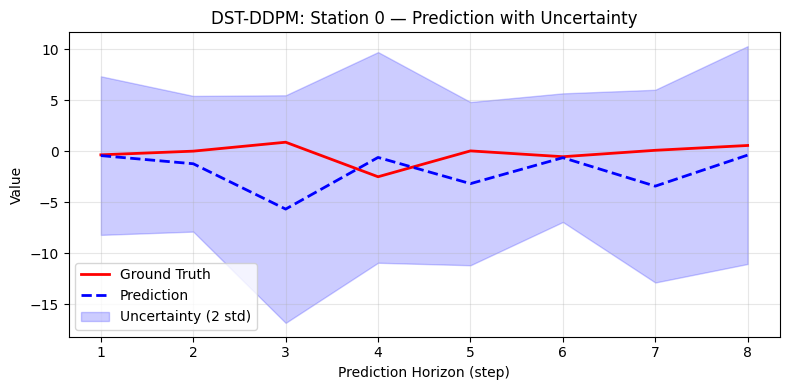

In [16]:
import matplotlib.pyplot as plt

station_idx = 0
gt = yb[0, :, station_idx, 0].cpu().numpy()
pred = mean_pred[0, :, station_idx, 0].cpu().numpy()
std = std_pred[0, :, station_idx, 0].cpu().numpy()
timesteps = np.arange(1, config.pred_len + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(timesteps, gt, 'r-', linewidth=2, label='Ground Truth')
ax.plot(timesteps, pred, 'b--', linewidth=2, label='Prediction')
ax.fill_between(timesteps, pred - 2 * std, pred + 2 * std, alpha=0.2, color='blue',
                label='Uncertainty (2 std)')
ax.set_xlabel('Prediction Horizon (step)')
ax.set_ylabel('Value')
ax.set_title(f'DST-DDPM: Station {station_idx} — Prediction with Uncertainty')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Visualize Diffusion Sampling Process (cf. Fig. 8)

Shows how the distribution converges from pure noise ($k=K$) to the learned data distribution ($k=0$).

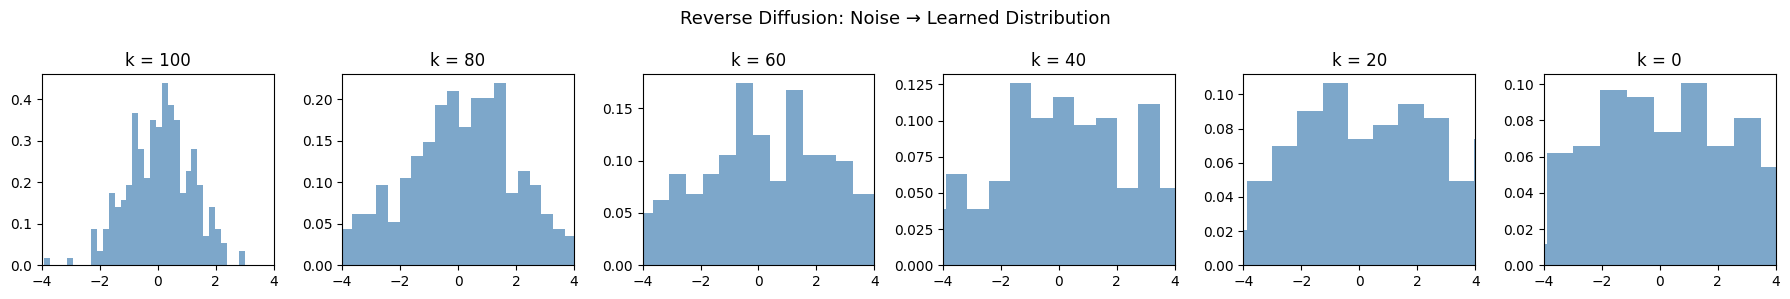

In [17]:
model.eval()
ema.apply(model)

xb_one = xb[:1]  # single sample
context, _ = model.context_encoder(xb_one, A_dist, A_sim)
K = config.diffusion_steps

x = torch.randn(1, config.pred_len, config.num_stations, 1, device=device)
snapshots = {}
checkpoints = [K, int(0.8 * K), int(0.6 * K), int(0.4 * K), int(0.2 * K), 0]

with torch.no_grad():
    for i in reversed(range(K)):
        k_vec = torch.full((1,), i, device=device, dtype=torch.long)
        eps = model.denoiser(x, k_vec, context)
        coeff = model.betas[i] / torch.sqrt(1.0 - model.alpha_bars[i])
        x = (1.0 / torch.sqrt(model.alphas[i])) * (x - coeff * eps)
        if i > 0:
            x = x + torch.sqrt(model.betas[i]) * torch.randn_like(x)

        if i + 1 in checkpoints:
            snapshots[i + 1] = x.clone().cpu().numpy().flatten()
    snapshots[0] = x.cpu().numpy().flatten()

fig, axes = plt.subplots(1, len(checkpoints), figsize=(18, 3))
for ax, cp in zip(axes, checkpoints):
    data = snapshots.get(cp, snapshots[0])
    ax.hist(data, bins=40, density=True, alpha=0.7, color='steelblue')
    ax.set_title(f'k = {cp}')
    ax.set_xlim(-4, 4)
fig.suptitle('Reverse Diffusion: Noise → Learned Distribution', fontsize=13)
plt.tight_layout()
plt.show()

ema.restore(model)

## Summary

| Component | Key Idea |
|---|---|
| **Dynamic Context Encoder** | Dual T-GCN → semantic fusion → learned dynamic adjacency (not static) → context embedding |
| **ST Denoising Model** | Spatial Transformer (over nodes) + Temporal Transformer (over time) + context fusion gates |
| **DDPM** | Conditional denoising diffusion; enables uncertainty quantification via multiple samples |

**To use with real data** (e.g. Delhi stations):
1. Replace `generate_random_data()` with your station hourly data shaped as `(samples, timesteps, N_stations, features)`
2. Compute `A_dist` from actual station lat/lon coordinates
3. Compute `A_sim` from station metadata similarity (or use identity / learned-only)
4. Adjust `config.num_stations`, `config.num_features`, `config.hist_len`, `config.pred_len`